# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

Alumna: Zhang Tan Rubi

Grupo: 6AM2

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

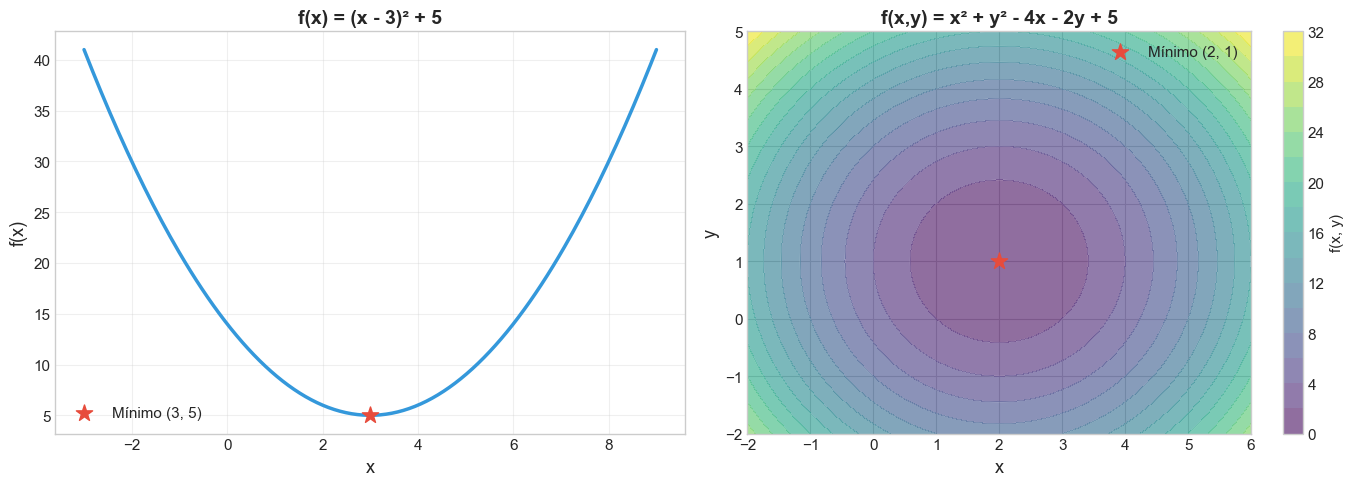

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [3]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    """

    # 1. Inicializamos las variables:
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    
    # 2. Loop principal (max_iter iteraciones):
    for i in range(max_iter):
        # a. Calculamos el gradiente
        g = df_1d(x_actual)
        # b. Actualizamos
        x_nuevo = x_actual - learning_rate * g
        # c. Guardamos en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        # d. Verificamos convergencia
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break
        # e. Actualizamos x_actual
        x_actual = x_nuevo
    
    # 3. Retornamos el diccionario con resultados
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [4]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


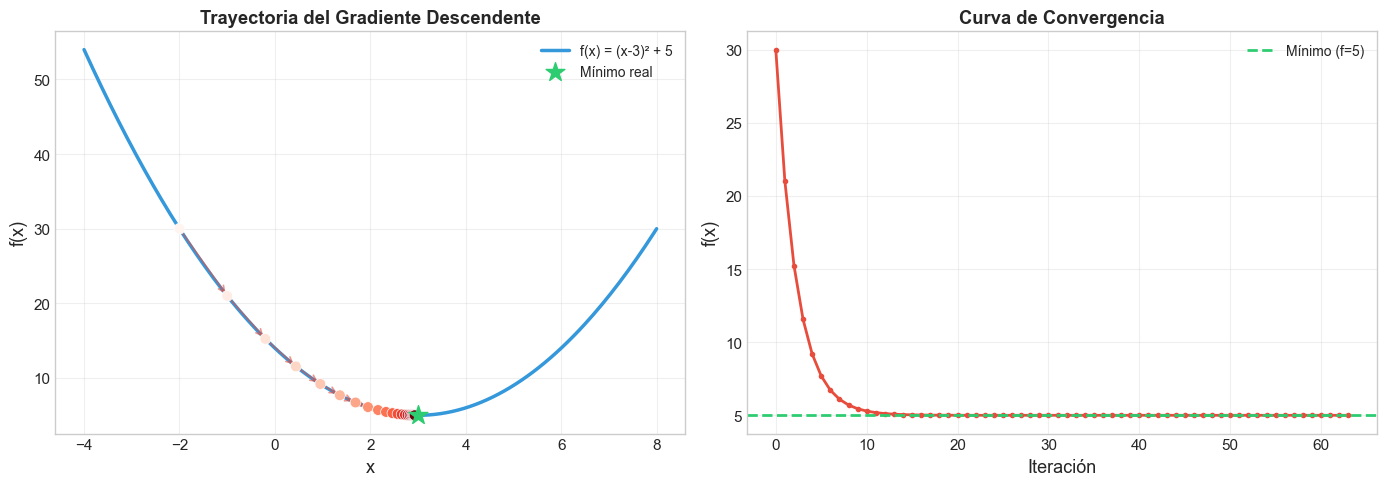

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [6]:
learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenamos resultados
resultados_lr = []

# Ejecutamos gradiente_descendente_1d para cada learning rate
for lr in learning_rates_prueba:
    resultado = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(resultado)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

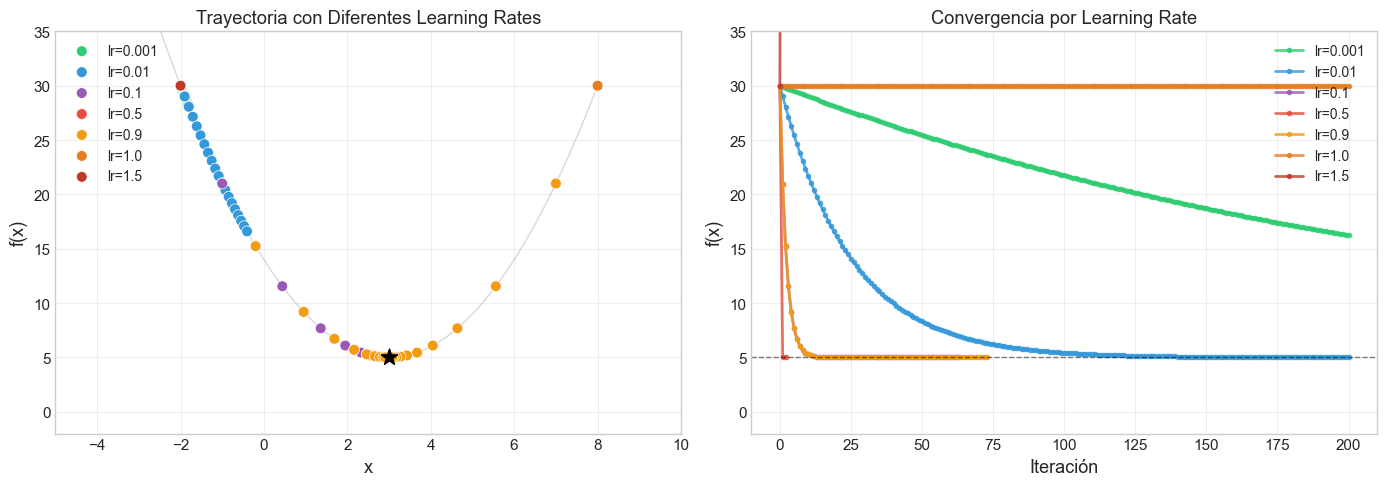

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_lr = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#e67e22', '#c0392b']

# Grafica 1: Trayectoria sobre f(x) para cada LR
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='gray', linewidth=1, alpha=0.3)
axes[0].scatter([3], [5], color='black', s=150, marker='*', zorder=10)

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores_lr):
    hx = res['historial_x']
    hf = res['historial_f']
    n_mostrar = min(20, len(hx))
    axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=[color]*n_mostrar, 
                   s=60, zorder=5, edgecolors='white', linewidth=0.5, label=f'lr={lr}')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria con Diferentes Learning Rates')
axes[0].legend(fontsize=10)
axes[0].set_ylim(-2, 35)
axes[0].set_xlim(-5, 10)
axes[0].grid(True, alpha=0.3)

# Grafica 2: Curva de convergencia f(x) vs iteracion para cada LR
for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores_lr):
    hf = res['historial_f']
    axes[1].plot(range(len(hf)), hf, 'o-', color=color, linewidth=2, 
                markersize=3, label=f'lr={lr}', alpha=0.8)

axes[1].axhline(y=5, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Convergencia por Learning Rate')
axes[1].legend(fontsize=10)
axes[1].set_ylim(-2, 35)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Responde estas preguntas basandote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - *Converge muy lentamente el algoritmo, requiere muchas iteraciones para llegar al mínimo. Los pasos son pequeños, el algoritmo avanza muy despacio. A pesar de las 200 iteraciones, el punto final sigue lejos del mínimo real.*

2. **¿Cuál consideras el mejor learning rate y por qué?**
   - *0.5 porque converge rápido, en pocas iteracionesy llegó exactamente a x=3.*

3. **¿Qué pasa con learning rates >= 1.0?**
   - *El algoritmo oscila sin avanzar. Los pasos son grandes que sobrepasa el mínimo y puede llegar a alejarse en lugar de acercarse.*

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - *Porque la derivada de f(x) = (x-3)² + 5 es f'(x) = 2(x-3). Con lr = 1.0, la actualización queda como: x_nuevo = x - 1.0 × 2(x-3) = x - 2x + 6 = -x + 6. Si se empieza en x = -2, va a 8, luego a -2, luego a 8, sin converger nunca.*

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [8]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    """

    # 1. Inicializamos:
    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False
    
    # 2. Loop principal:
    for i in range(max_iter):
        # a. Calculamos gradiente
        g = grad_2d(x_actual, y_actual)
        gx, gy = g[0], g[1]
        # b. Actualizamos ambos parametros
        x_nuevo = x_actual - learning_rate * gx
        y_nuevo = y_actual - learning_rate * gy
        # c. Guardamos en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        # d. Verificamos convergencia (norma del gradiente) si ||gradiente|| < tolerancia
        norma_gradiente = np.linalg.norm(g)
        if norma_gradiente < tolerancia:
            convergido = True
            x_actual = x_nuevo
            y_actual = y_nuevo
            break
        # e. Actualizamos posicion
        x_actual = x_nuevo
        y_actual = y_nuevo
    
    # 3. Retornamos diccionario con resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [9]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


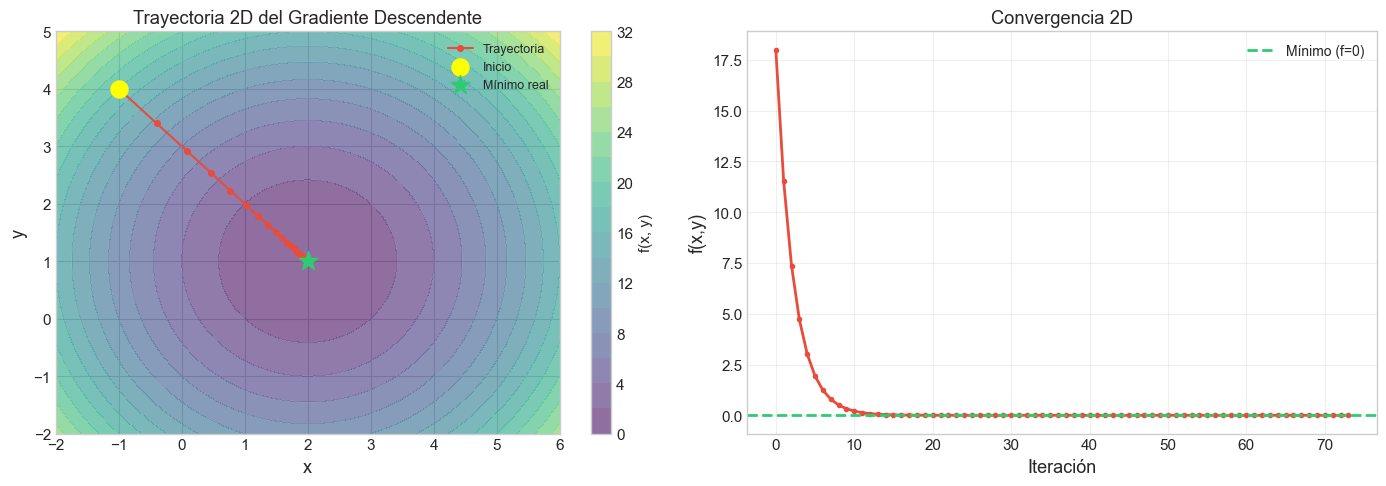

In [10]:
# Visualizacion del gradiente descendente 2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de contornos de la funcion f(x, y)
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

# Grafica 1: Trayectoria sobre contornos
contour = axes[0].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[0].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[0], label='f(x, y)')

hx2 = resultado_2d['historial_x']
hy2 = resultado_2d['historial_y']
axes[0].plot(hx2, hy2, 'o-', color='#e74c3c', markersize=4, linewidth=1.5, label='Trayectoria')
axes[0].scatter([hx2[0]], [hy2[0]], color='yellow', s=150, marker='o', zorder=6, label='Inicio')
axes[0].scatter([2], [1], color='#2ecc71', s=200, marker='*', zorder=7, label='Mínimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Trayectoria 2D del Gradiente Descendente')
axes[0].legend(fontsize=9)

# Grafica 2: Convergencia
axes[1].plot(range(len(resultado_2d['historial_f'])), resultado_2d['historial_f'],
             'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=0)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x,y)', fontsize=13)
axes[1].set_title('Convergencia 2D')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png')
plt.show()

In [11]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Probamos con 3 puntos iniciales diferentes y comparamos los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

print("EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES (2D)")
print("=" * 70)
print(f"{'Punto Inicial':>20} {'(x,y) Final':>20} {'f(x,y)':>12} {'Iter':>8}")
print("-" * 70)

for px, py in puntos_iniciales:
    res = gradiente_descendente_2d(px, py, learning_rate=0.1, max_iter=100)
    print(f"  ({px:>4}, {py:>4}) {res['x_final']:>8.4f},     {res['y_final']:>8.4f}      {res['f_final']:>12.6f} {res['iteraciones']:>8}")


EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES (2D)
       Punto Inicial          (x,y) Final       f(x,y)     Iter
----------------------------------------------------------------------
  (-1.0,  4.0)   2.0000,       1.0000          0.000000       73
  ( 5.0, -1.0)   2.0000,       1.0000          0.000000       72
  ( 0.0,  0.0)   2.0000,       1.0000          0.000000       70


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [12]:
# Generamos el DataFrame con todos los experimentos

# 1. Ejecutamos TODOS los experimentos:
experimentos = []

# Experimentos 1D
for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    experimentos.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': -2.0,
        'y_inicial': np.nan,
        'x_final': res['x_final'],
        'y_final': np.nan,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

# Experimentos 2D
lr_2d = [0.001, 0.01, 0.1, 0.5]
for xi, yi in puntos_iniciales:
    for lr in lr_2d:
        res = gradiente_descendente_2d(x_inicial=xi, y_inicial=yi, learning_rate=lr, max_iter=200)
        experimentos.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': xi,
            'y_inicial': yi,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

# 2. Creamos el DataFrame
df_experimentos = pd.DataFrame(experimentos)

# 3. Guardalomos como CSV
df_experimentos = df_experimentos.fillna('NaN')
df_experimentos.to_csv('experimentos_gd.csv', index=False)


In [13]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - *De 0.01 a 0.5, ya que menor a 0.01 converge muy lento, mayor a 1.0 comienza a oscilar, pero de 0.01 a 0.5 converge rápido y de forma estable.*

2. **¿El punto inicial afecta si el algoritmo converge? ¿Afecta cuántas iteraciones necesita?**
   - *Para funciones convexas como esta, el punto inicial no afecta si el algoritmo converge o no, ya que siempre llega al mínimo (único), pero sí afecta cuántas iteraciones necesita.*

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x²/10`)**
   - *El algoritmo quedaría atrapado en el mínimo local más cercano al punto inicial, diferentes puntos iniciales podrían llevar a diferentes mínimos.*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`. ¿Por qué es importante elegir bien el learning rate al entrenar?**
   - *Un LR muy pequeño hace que el entrenamiento sea muy lento y un LR muy alto puede hacer que el modelo nunca converja. Por lo tanto, un LR óptimo balancea ambas cosas, la velocidad de convergencia con estabilidad, usando menos recursos computacionales y en poco tiempo.*

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *El gradiente dice exactamente en qué dirección está el descenso más pronunciado para reducir el error más rápido. En cambio, buscar al azar es menos eficiente, ya que en redes neuronales con muchos parámetros puede ser computacionalmente imposible.*

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [14]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [15]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    """

    # 1. Inicializamos 
    w = 0
    b = 0
    n = len(X)
    historial_loss = []
    historial_w = []
    historial_b = []

    # 2. Para cada epoch
    for epoch in range(epochs):
        # a. Mezclamos los indices aleatoriamente
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # b. Para cada mini-batch
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            # Calculamos prediccion: y_pred = w * X_batch + b
            y_pred = w * X_batch + b
            # Calculamos error: error = y_batch - y_pred
            error = y_batch - y_pred
            # Calculamos gradientes
            dw = -2 / len(X_batch) * np.sum(error * X_batch)
            db = -2 / len(X_batch) * np.sum(error)
            # Actualizamos: w = w - lr * dw, b = b - lr * db
            w = w - learning_rate * dw
            b = b - learning_rate * db

        # c. Calculamos MSE del epoch completo y guardamos en historial
        y_pred_total = w * X + b
        mse = np.mean((y - y_pred_total) ** 2)
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

w final: 3.1819  (real: 3.0)
b final: 6.1485  (real: 7.0)
MSE final: 4.0841


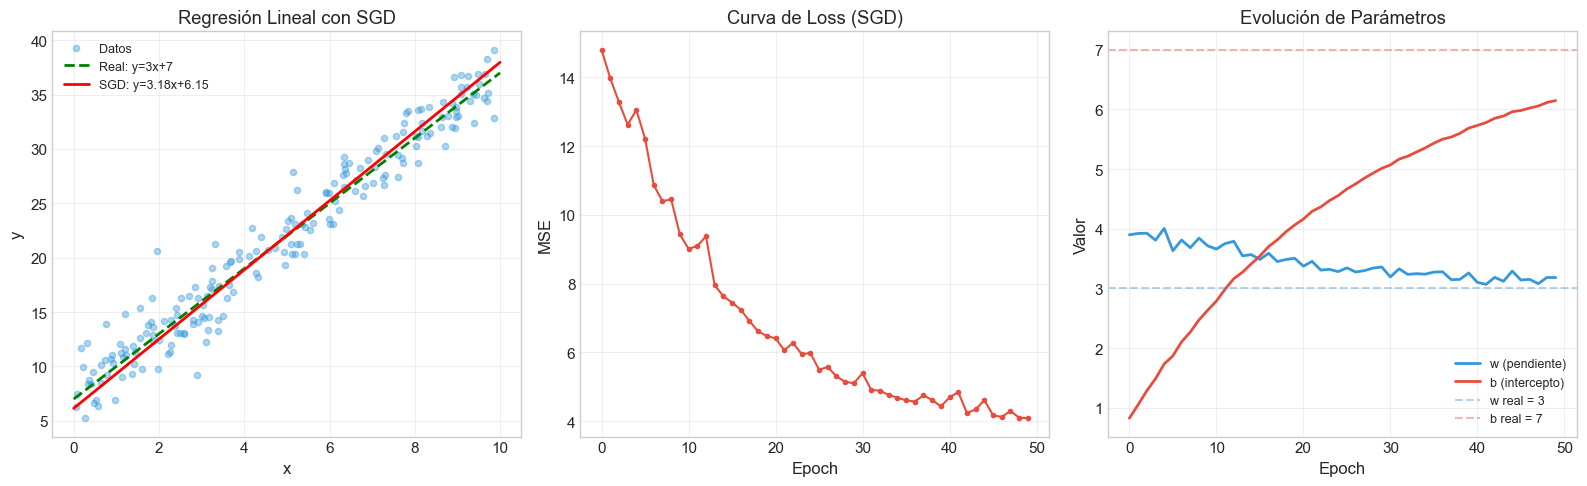

In [16]:
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

print(f"w final: {resultado_sgd['w_final']:.4f}  (real: 3.0)")
print(f"b final: {resultado_sgd['b_final']:.4f}  (real: 7.0)")
print(f"MSE final: {resultado_sgd['historial_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafica 1: Datos + linea aprendida vs linea real
x_line = np.linspace(0, 10, 100)
axes[0].scatter(X_sgd, y_sgd, alpha=0.4, s=20, color='#3498db', label='Datos')
axes[0].plot(x_line, 3*x_line + 7, 'g--', linewidth=2, label='Real: y=3x+7')
axes[0].plot(x_line,
             resultado_sgd['w_final']*x_line + resultado_sgd['b_final'],
             'r-', linewidth=2,
             label=f"SGD: y={resultado_sgd['w_final']:.2f}x+{resultado_sgd['b_final']:.2f}")
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Regresión Lineal con SGD')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Grafica 2: Curva de loss por epoch
axes[1].plot(resultado_sgd['historial_loss'], 'o-', color='#e74c3c',
             markersize=3, linewidth=1.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('Curva de Loss (SGD)')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Evolucion de w y b por epoch
axes[2].plot(resultado_sgd['historial_w'], color='#3498db', linewidth=2, label='w (pendiente)')
axes[2].plot(resultado_sgd['historial_b'], color='#e74c3c', linewidth=2, label='b (intercepto)')
axes[2].axhline(y=3, color='#3498db', linestyle='--', alpha=0.4, label='w real = 3')
axes[2].axhline(y=7, color='#e74c3c', linestyle='--', alpha=0.4, label='b real = 7')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Valor', fontsize=12)
axes[2].set_title('Evolución de Parámetros')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

batch_sizes = [1, 8, 32, 64, len(X_sgd)]  # 1=SGD puro, n=GD puro

print("\nCOMPARACIÓN GD vs SGD con diferentes batch_sizes")
print("=" * 60)
print(f"{'Batch Size':>12} {'w Final':>12} {'b Final':>12} {'MSE Final':>12}")
print("-" * 60)

resultados_batch = []

# Ejecutamos para cada batch_size y comparamos convergencia
for bs in batch_sizes:
    np.random.seed(42)
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_batch.append(res)
    nombre = "GD (completo)" if bs == n_datos else "SGD" if bs == 1 else f"Batch ({bs})"
    print(f"{nombre:>12} {res['w_final']:>12.4f} {res['b_final']:>12.4f} {res['historial_loss'][-1]:>12.4f}")



COMPARACIÓN GD vs SGD con diferentes batch_sizes
  Batch Size      w Final      b Final    MSE Final
------------------------------------------------------------
         SGD       3.4440       7.3376      11.0936
   Batch (8)       2.9987       7.2076       3.7415
  Batch (32)       3.1362       6.1491       4.0413
  Batch (64)       3.3052       4.8658       5.2528
GD (completo)       3.7556       2.1410      10.6685


**Preguntas Bonus:**

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *El GD puro calcula el gradiente usando todos los datos en cada iteración, sus actualizaciones son más estables pero es más lento, obtuvo un b_final = 2.14, el cual es lejano del valor real (7). En cambio, SDG usa solo un dato por iteración, por lo que las actualizaciones son más rápidas pero ruidosas.*

2. **¿Cuál batch_size te dio los mejores resultados? ¿Por qué?**
   - *El de size 8 dio el MSE más bajo de 3.74, ya que logra un equilibrio entre la estabilidad de GD y las actualizaciones frecuentes de SGD. Los valores de w_final = 2.99 y b_final = 7.20 más cercanos a los reales (3 y 7).*

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**
   - *En SGD cada paso el gradiente se calcula con solo un subconjunto aleatorio de los datos, lo que produce una estimación ruidosa del gradiente real. En cambio, GD usa todos los datos, por lo que su gradiente es preciso y el loss siempre es suave y estable.*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_